# Jacobi Polynomials from OEIS Sequence A027614

This notebook explores the coefficient matrix of Jacobi polynomials $P_n^{(\mu,\nu)}(x)$ and its connection to the OEIS sequence **A027614**.

## Overview

The Jacobi polynomials $P_n^{(\mu,\nu)}(x)$ form a two-parameter family of orthogonal polynomials. Their coefficients (in the monomial basis) assemble into a lower-triangular **Jacobi maxel** $J$ where $J[n,k]$ is the coefficient of $x^k$ in $P_n^{(\mu,\nu)}(x)$ (up to normalization). The entries of its matrix logarithm $\log J$ are governed by A027614.

**Steps:**
1. Load A027614 coefficients $a_0, a_1, \ldots$
2. Build the subdiagonal shift matrix $L$ with $L[i,\, i{-}1] = \mu + i$
3. Form the series $G(x) = \sum_{k=1}^{\infty} (-1)^{k+1} \frac{a_k}{k!}\, x^k$ (EGF shape) and evaluate at $x = L$
4. Apply diagonal similarity transforms with Pochhammer symbols to extract $\log J$
5. Exponentiate to recover the normalized Jacobi matrix $J_\text{norm}$
6. Left-multiply by the Jacobi prefactor diagonal $D_J$ to obtain the full coefficient matrix $J$

In [1]:
import os
from pathlib import Path
from sympy import (
    symbols, init_printing, factor, simplify, together,
    Matrix, factorial, RisingFactorial,
)
from IPython.display import display, Markdown

init_printing(use_latex=True)

# Change to project root so relative OEIS paths resolve
os.chdir(Path("__file__").resolve().parent.parent if "__file__" in dir() else Path.cwd().parent)

from maxel.common import A027614_FP
from maxel.sequences import load_sequences, load_and_assign_to
from maxel.matrix import matrix_from_str, matrix_from_func, EMatrixType

## Parameters

In [2]:
n = 4                        # matrix size (n×n)
mu, nu = symbols("mu nu")   # keep symbolic; substitute integers to evaluate

## Helper functions

In [3]:
def make_diag_left(n):
    """Diagonal matrix D_L with D_L[j,j] = (mu+nu+1)_{2j} (even Pochhammer)."""
    def func_expr(i, j):
        return f"RisingFactorial(mu+nu+1,{2*j})"
    return matrix_from_func(func_expr, EMatrixType.DIAGONAL, n)


def make_diag_right(n):
    """Diagonal matrix D_R with D_R[j,j] = (mu+nu+1)_{2j+1} (odd Pochhammer)."""
    def func_expr(i, j):
        return f"RisingFactorial(mu+nu+1,{2*j+1})"
    return matrix_from_func(func_expr, EMatrixType.DIAGONAL, n)


def make_jacobi_diag(n):
    """Diagonal matrix D_J with D_J[i,i] = (mu+nu+i+1)_i / i!."""
    def func_expr(i, j):
        return f"RisingFactorial(mu+nu+i+1,j)/factorial({j})"
    return matrix_from_func(func_expr, EMatrixType.DIAGONAL, n).applyfunc(factor)

## Step 1 — Load A027614

OEIS sequence **A027614** provides integers $a_0, a_1, a_2, \ldots$ The first $n$ values are loaded and bound to symbolic variables, so they can be substituted into matrix expressions later.

In [4]:
raw_values = load_sequences(A027614_FP)
print(f"First {n} terms of A027614:")
for k, v in enumerate(raw_values[:10]):
    print(f"  a_{k} = {v}")
print("  ...")

list_a = symbols(",".join([f"a{i}" for i in range(n)]))
dict_a = load_and_assign_to(A027614_FP, list_a)

First 4 terms of A027614:
  a_0 = 0
  a_1 = 1
  a_2 = 1
  a_3 = 3
  a_4 = 14
  a_5 = 80
  a_6 = 468
  a_7 = 2268
  a_8 = 10224
  a_9 = 313632
  ...


## Step 2 — Subdiagonal shift matrix $L$

The matrix $L$ has a single non-zero subdiagonal:
$$L[i,\, i-1] = \mu + i \quad (i \geq 1), \qquad \text{all other entries } 0.$$
Since $L$ is strictly lower triangular, $L^n = 0$, so any power series in $L$ terminates at degree $n-1$.

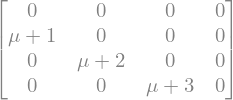

In [5]:
def func_expr(i, j):
    return "mu+i" if i == j + 1 else "0"

L = matrix_from_func(func_expr, EMatrixType.LOWER, n)
display(L)

## Step 3 — The series $G(x)$ evaluated at $L$

The series built from A027614 is:
$$G(x) = \sum_{k=1}^{\infty} (-1)^{k+1} \frac{a_k}{k!}\, x^k$$
Its coefficients $a_k / k!$ give it the form of an **EGF** (exponential generating function). Evaluating $G$ at the matrix $L$ yields $G(L)$, which is the matrix logarithm of a normalized Jacobi matrix (up to conjugation).

G(x) with symbolic a_k :


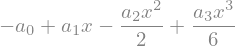

G(x) after substituting A027614 values:


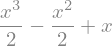

In [6]:
x = symbols("x")
G_scalar_sym = sum(
    (-1) ** (k + 1) * a_k / factorial(k) * x**k
    for k, a_k in enumerate(list_a)
)
print("G(x) with symbolic a_k :")
display(G_scalar_sym)

G_scalar = G_scalar_sym.subs(dict_a)
print("G(x) after substituting A027614 values:")
display(G_scalar)

G(L) with symbolic a_k :


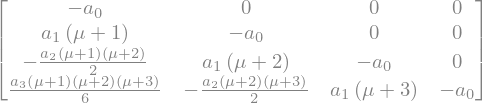

G(L) after substituting A027614 values:


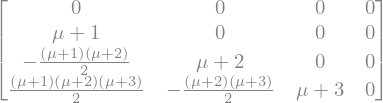

In [7]:
G_sym = Matrix.zeros(n)
for k, a_k in enumerate(list_a):
    G_sym += ((-1) ** (k + 1) * a_k / factorial(k)) * L**k
G_sym = G_sym.applyfunc(factor)
print("G(L) with symbolic a_k :")
display(G_sym)

G = G_sym.subs(dict_a).applyfunc(factor)
print("G(L) after substituting A027614 values:")
display(G)

## Step 4 — Pochhammer scaling to extract $\log J$

Two diagonal matrices built from the Pochhammer (rising factorial) symbol $(\alpha)_k = \alpha(\alpha+1)\cdots(\alpha+k-1)$:
$$D_L[j,j] = (\mu+\nu+1)_{2j} \qquad D_R[j,j] = (\mu+\nu+1)_{2j+1}$$
The product $D_L^{-1} \cdot G(L) \cdot D_R$ strips the Pochhammer weight from rows and columns. A further conjugation by $\operatorname{diag}(i!)$ normalizes the scaling, yielding $\log J$.

D_L — even Pochhammer diagonal:


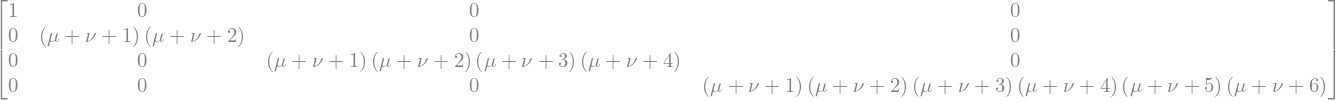

D_R — odd Pochhammer diagonal:


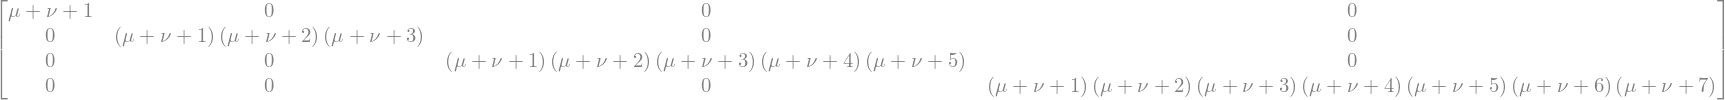

In [8]:
D_L = make_diag_left(n)
D_R = make_diag_right(n)
print("D_L — even Pochhammer diagonal:")
display(D_L)
print("D_R — odd Pochhammer diagonal:")
display(D_R)

$D_L^{-1} \cdot G(L) \cdot D_R$ :

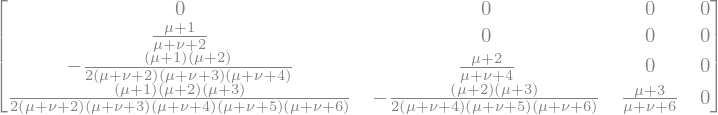

$\log J = \operatorname{diag}(i!) \cdot [D_L^{-1}\, G(L)\, D_R] \cdot \operatorname{diag}(j!)^{-1}$ :

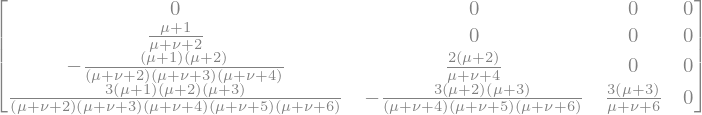

In [9]:
log_J = (D_L.inv() * G * D_R).applyfunc(factor)
display(Markdown("$D_L^{-1} \\cdot G(L) \\cdot D_R$ :"))
display(log_J)

diag_fact = matrix_from_str("factorial(i)", EMatrixType.DIAGONAL, n)
log_J = (diag_fact * log_J * diag_fact.inv()).applyfunc(factor)
display(Markdown("$\\log J = \\operatorname{diag}(i!) \\cdot [D_L^{-1}\\, G(L)\\, D_R] \\cdot \\operatorname{diag}(j!)^{-1}$ :"))
display(log_J)

## Step 5 — Exponentiate to recover the normalized Jacobi matrix

Taking the matrix exponential undoes the logarithm:
$$J_\text{norm} = \exp(\log J)$$

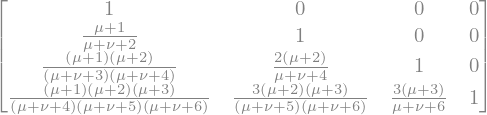

In [10]:
J_norm = log_J.exp().applyfunc(factor)
display(J_norm)

## Step 6 — Jacobi coefficient matrix $J$

The diagonal prefactor
$$D_J[i,i] = \frac{(\mu+\nu+i+1)_i}{i!}$$
encodes the leading normalization of $P_n^{(\mu,\nu)}$. Left-multiplying recovers the full coefficient matrix:
$$J = D_J \cdot J_\text{norm}$$

Jacobi prefactor diagonal $D_J$ :

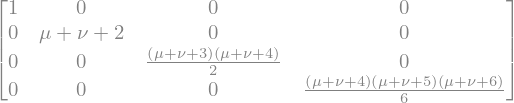

Jacobi coefficient matrix $J$ :

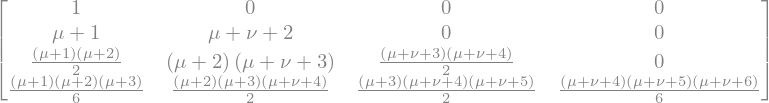

The rows of $J$ are the coefficients of the Jacobi polynomials: $$P_n^{(\mu,\nu)}(z) = \sum_{k=0}^{n} J[n,k]\, \left(\frac{z-1}{2}\right)^k$$

In [11]:
D_J = make_jacobi_diag(n)
display(Markdown("Jacobi prefactor diagonal $D_J$ :"))
display(D_J)

J = (D_J * J_norm).applyfunc(factor)
display(Markdown("Jacobi coefficient matrix $J$ :"))
display(J)

display(Markdown(
    r"The rows of $J$ are the coefficients of the Jacobi polynomials: "
    r"$$P_n^{(\mu,\nu)}(z) = \sum_{k=0}^{n} J[n,k]\, \left(\frac{z-1}{2}\right)^k$$"
))

## Full formula

$$J = D_J \cdot \exp\!\Bigl(\operatorname{diag}(i!) \cdot D_L^{-1} \cdot G(L) \cdot D_R \cdot \operatorname{diag}(j!)^{-1}\Bigr)$$

where

$$G(L) = \sum_{k=1}^{\infty} (-1)^{k+1} \frac{a_k}{k!}\, L^k, \qquad L[i,\,i-1] = \mu + i$$

and the diagonal matrices are:

$$D_L[j,j] = (\mu+\nu+1)_{2j}, \qquad D_R[j,j] = (\mu+\nu+1)_{2j+1}, \qquad D_J[i,i] = \frac{(\mu+\nu+i+1)_i}{i!}$$